# 04 — Comparing Methods with ComparisonReport

**ComparisonReport** takes a results DataFrame and produces summary tables,
rankings, and plots to compare fairness methods side by side. This notebook
focuses on the report API — for running experiments automatically, see
notebook 05.

## Build a results DataFrame

We run a few methods with 2-fold CV on the Ricci dataset to create the
input DataFrame that ComparisonReport expects.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from skfair.datasets import load_ricci
from skfair.preprocessing import FairSmote, Massaging, ReweighingClassifier
from skfair.metrics import accuracy, statistical_parity_difference, average_odds_difference

X, y = load_ricci(preprocessed=True)
sens = X["Race"]
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

methods = {
    "Baseline": None,
    "FairSmote": FairSmote(sens_attr="Race", random_state=42),
    "Massaging": Massaging(sens_attr="Race"),
    "ReweighingClf": ReweighingClassifier(
        estimator=LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
        sens_attr="Race",
    ),
}

rows = []
for name, method in methods.items():
    acc_scores, spd_scores, aod_scores = [], [], []
    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        if name == "ReweighingClf":
            method.fit(X_tr, y_tr)
            y_pred = method.predict(X_te)
        else:
            if method is not None:
                X_tr, y_tr = method.fit_resample(X_tr, y_tr)
            clf = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)

        acc_scores.append(accuracy(y_te, y_pred))
        spd_scores.append(statistical_parity_difference(y_te, y_pred, X_te["Race"]))
        aod_scores.append(average_odds_difference(y_te, y_pred, X_te["Race"]))

    rows.append({
        "dataset": "ricci", "method": name, "classifier": "LogReg",
        "accuracy": np.mean(acc_scores),
        "spd": np.mean(spd_scores),
        "aod": np.mean(aod_scores)
    })

results_df = pd.DataFrame(rows)
results_df

,dataset,method,classifier,accuracy,spd,aod
0,ricci,Baseline,LogReg,0.703390,-0.667959,-0.559401
1,ricci,FairSmote,LogReg,0.788136,-0.064761,0.097076
2,ricci,Massaging,LogReg,0.618644,0.066118,0.135347
3,ricci,ReweighingClf,LogReg,0.754237,-0.019847,0.123389


## Create a ComparisonReport

The report expects columns: `dataset`, `method`, `classifier`, plus one column per metric (e.g. `accuracy`, `spd`).

In [2]:
from skfair.comparison import ComparisonReport

report = ComparisonReport(results_df)

## Summary tables

In [ ]:
# Default: average over classifiers
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name}  ---")
    display(df)

--- ricci ---


,accuracy,spd,aod
method,,,
Baseline,0.7034,-0.6680,-0.5594
FairSmote,0.7881,-0.0648,0.0971
Massaging,0.6186,0.0661,0.1353
ReweighingClf,0.7542,-0.0198,0.1234


## Performance bar plot

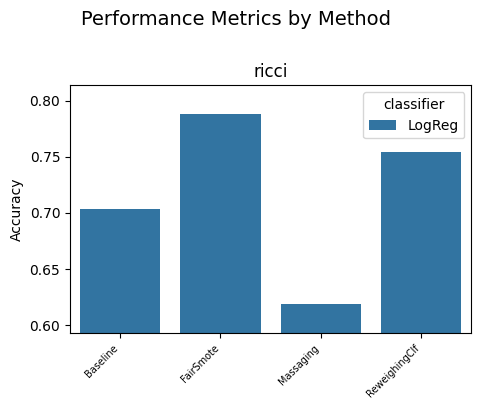

In [5]:
report.plot_performance();

## Fairness bar plot

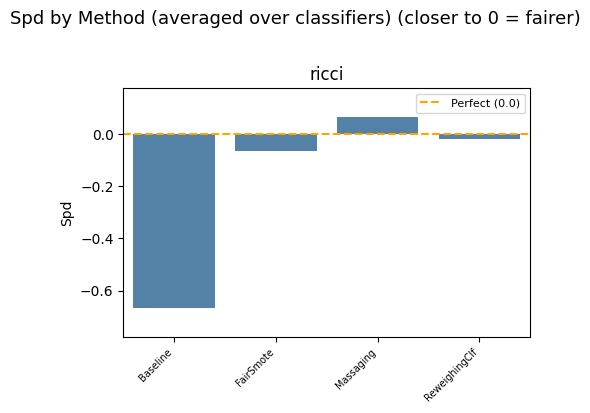

In [6]:
report.plot_fairness_averaged(metric="spd");

## Trade-off scatter

Plots accuracy vs fairness (SPD). Ideally a method sits in the top-right
corner (high accuracy, SPD close to zero).

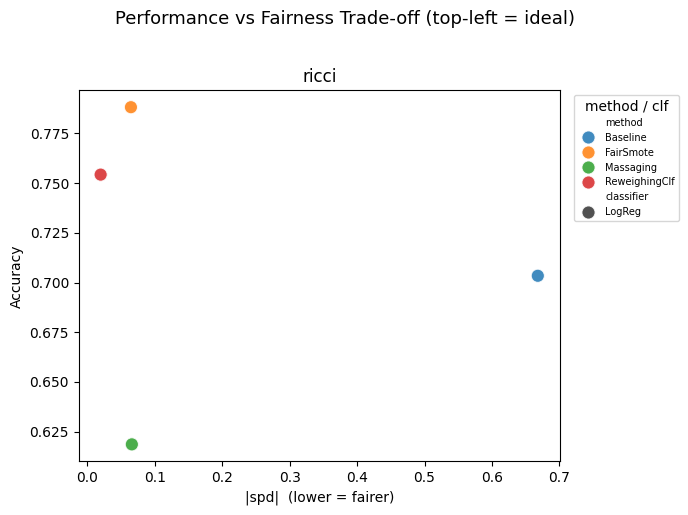

In [7]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");

## Ranking heatmap

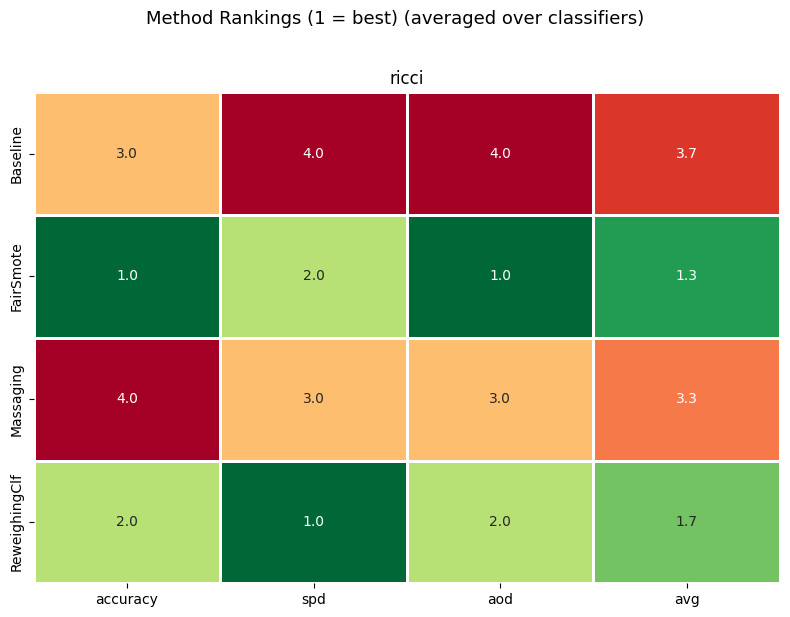

In [8]:
report.plot_ranking();